In [ ]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces
import math


class InitialEnv(gym.Env):

    def __init__(
            self,
            n_hours=24,             # Number of time steps in an episode
            alpha=0.5,              # Efficiency factor for P1
            beta=0.5,               # Efficiency factor for P2
            lambda_penalty=100,     # Penalty weight for unmet demand
            ):
        super().__init__()
        self.n_hours = int(n_hours)
        self.a = float(alpha)
        self.b = float(beta)
        self.lambda_penalty = float(lambda_penalty)


        # Spaces
        self.action_space = spaces.Box(
            low=np.zeros(4, dtype=np.float32),
            high=np.ones(4, dtype=np.float32),
            dtype=np.float32,
        ) # [u0, u1, u2, u3]

        self.observation_space = spaces.Box(
            low=np.zeros(5, dtype=np.float32),
            high=np.array([1.0, 200.0, 200.0, 20.0, 20.0], dtype=np.float32),
            dtype=np.float32,
        ) # [t_norm, solar, wind, demand_1, demand_2]


    

    # Reset generates a new random episode with stochastic profiles
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0

        rng = self.np_random

        T = range(self.n_hours)

        max_tries = 50

        # Try generating profiles until we get a feasible episode (demand can be met by production)
        for _ in range(max_tries):
            
            # Generate random demand scale and energy profiles
            demand_scale, solar, wind = self.generate_energy_profiles(rng, T)

            # Generate random demand profiles
            demand_1, demand_2 = self.generate_demands(rng, T, demand_scale)

            # Clip profiles to ensure non-negativity
            solar = np.clip(solar, 0.0, None)
            wind = np.clip(wind, 0.0, None)
            demand_1 = np.clip(demand_1, 0.0, None)
            demand_2 = np.clip(demand_2, 0.0, None)


            # Check feasibility: can the demand be met by the available energy at every time step (t)?
            feasible = np.all((demand_1 / self.a + demand_2 / self.b) <= (solar + wind) + 1e-6)
            if feasible:
                break
        else:
            raise RuntimeError("Failed to generate a feasible episode after max_tries")

        

        self.solar = solar
        self.wind = wind
        self.demand_1 = demand_1
        self.demand_2 = demand_2

        t_norm = 0.0
        obs = np.array([t_norm, self.solar[self.t], self.wind[self.t], self.demand_1[self.t], self.demand_2[self.t]], dtype=np.float32)
        return obs, {}

    
    def step(self, action):


        # Get current profiles
        available_solar = float(self.solar[self.t])
        available_wind = float(self.wind[self.t]) 
        demand_1 = float(self.demand_1[self.t])   
        demand_2 = float(self.demand_2[self.t])  


        # Parse action
        U11, U12, U21, U22 = [float(x) for x in np.clip(action, 0.0, 1.0)]

        # Calculate energies based on Uij
        E11 = U11 * available_solar            
        E12 = U12 * (1-U11) * available_solar  
        E21 = U21 * available_wind             
        E22 = U22 * (1-U21) * available_wind

        # Calculate final production
        P1 = self.a * (E11 + E21)
        P2 = self.b * (E12 + E22)

        # Calculate penalties for unmet demand
        penalty_1 = max(0.0, demand_1 - P1)
        penalty_2 = max(0.0, demand_2 - P2)

        # Reward: production minus penalties
        reward = P1 + P2 - (self.lambda_penalty * (penalty_1 + penalty_2))

        info = {
            "t": self.t,
            "solar": available_solar,
            "wind": available_wind,
            "demand_1": demand_1,
            "demand_2": demand_2,
            "E11": E11,
            "E12": E12,
            "E21": E21,
            "E22": E22,
            "P1": P1,
            "P2": P2,
        }

        # Advance time
        self.t += 1
        terminated = (self.t >= self.n_hours)
        truncated = False

        if terminated:
            obs = np.zeros(5, dtype=np.float32)
        else:
            t_norm = self.t / (self.n_hours - 1)
            obs = np.array([t_norm, self.solar[self.t], self.wind[self.t], self.demand_1[self.t], self.demand_2[self.t]], dtype=np.float32)

        return obs, float(reward), terminated, truncated, info
    

    def generate_demands(self, rng, T, demand_scale):
        demand_1 = np.array([5.0 + 1.0 * math.sin(2 * math.pi * t / self.n_hours) for t in T], dtype=np.float32)
        demand_2 = np.array([4.0 + 1.0 * math.cos(2 * math.pi * t / self.n_hours) for t in T], dtype=np.float32)

        demand_1 *= demand_scale * (1.0 + rng.normal(0.0, 0.02, size=self.n_hours)).astype(np.float32)
        demand_2 *= demand_scale * (1.0 + rng.normal(0.0, 0.02, size=self.n_hours)).astype(np.float32)
        return demand_1,demand_2

    def generate_energy_profiles(self, rng, T):
        solar_peak = rng.uniform(40.0, 80.0)
        cloud_factor = rng.uniform(0.2, 1.0)
        wind_mean = rng.uniform(20.0, 50.0)
        wind_sigma = rng.uniform(2.0, 8.0)
        demand_scale = rng.uniform(0.85, 1.15)

            # Solar base shape (triangular with peak at midday)
        solar = np.zeros(self.n_hours, dtype=np.float32)
        for t in T:
            if 6 <= t < 18:
                solar[t] = solar_peak * (1.0 - abs(t - 12) / 6.0)
            # Apply cloudiness + noise
        solar *= cloud_factor
        solar *= (1.0 + rng.normal(0.0,0.05, size=self.n_hours)).astype(np.float32)

            # Wind: mean + noise
        wind = (wind_mean + rng.normal(0.0, wind_sigma, size=self.n_hours)).astype(np.float32)
        return demand_scale,solar,wind


In [2]:
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt
import numpy as np

def calculate_optimal_episode_reward(solar, wind, demand_1, demand_2, a=0.5, b=0.5, plot=False):
    """
    Calculates the maximum possible reward for a specific episode's profiles.
    """
    solver = pywraplp.Solver.CreateSolver("GLOP")
    if not solver:
        raise RuntimeError("Could not create OR-Tools GLOP solver")

    n_hours = len(solar)
    T = range(n_hours)

    # Decision variables
    E11 = [solver.NumVar(0.0, float(solar[t]), f"E11_{t}") for t in T]
    E12 = [solver.NumVar(0.0, float(solar[t]), f"E12_{t}") for t in T]
    E21 = [solver.NumVar(0.0, float(wind[t]), f"E21_{t}") for t in T]
    E22 = [solver.NumVar(0.0, float(wind[t]), f"E22_{t}") for t in T]

    # Production variables
    P1 = [solver.NumVar(0.0, solver.infinity(), f"P1_{t}") for t in T]
    P2 = [solver.NumVar(0.0, solver.infinity(), f"P2_{t}") for t in T]

    # Constraints
    for t in T:
        solver.Add(E11[t] + E12[t] <= float(solar[t]))
        solver.Add(E21[t] + E22[t] <= float(wind[t]))

        solver.Add(P1[t] == a * (E11[t] + E21[t]))
        solver.Add(P2[t] == b * (E12[t] + E22[t]))

        # Hard constraints for demand (safe because env guarantees feasibility)
        solver.Add(P1[t] >= float(demand_1[t]))
        solver.Add(P2[t] >= float(demand_2[t]))

    # Objective: maximize total production
    solver.Maximize(solver.Sum(P1[t] + P2[t] for t in T))
    
    status = solver.Solve()

    if status != pywraplp.Solver.OPTIMAL:
        print("Warning: No optimal solution found. Is the episode actually feasible?")
        return 0.0

    optimal_reward = solver.Objective().Value()

    # Optional plotting logic for visual verification
    if plot:
        res_P1 = [P1[t].solution_value() for t in T]
        res_P2 = [P2[t].solution_value() for t in T]
        
        plt.figure(figsize=(12, 4))
        plt.plot(T, res_P1, label="P1 (Production 1)", linestyle='--')
        plt.plot(T, demand_1, label="P1 Demand", linestyle=':')
        plt.plot(T, res_P2, label="P2 (Production 2)", linestyle='--')
        plt.plot(T, demand_2, label="P2 Demand", linestyle=':')
        plt.xlabel("Hour")
        plt.ylabel("Energy")
        plt.title("Simplex Optimal Production vs Demand")
        plt.legend()
        plt.show()

    return optimal_reward

In [ ]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
import numpy as np


def train_agent():
    # 1. Create the Environment
    # We wrap it in a DummyVecEnv which is required for SB3 (even for 1 env)
    env = make_vec_env(lambda: InitialEnv(n_hours=24, alpha=0.5, beta=0.5), n_envs=1)

    # 2. Define the Model (The "Brain")
    # "MlpPolicy": Multi-Layer Perceptron (standard dense neural network)
    model = PPO(
        "MlpPolicy", 
        env, 
        verbose=1, 
        learning_rate=0.0003,
        batch_size=64,
        gamma=0.99  # Discount factor (future rewards matter)
    )

    # 3. Evaluate before training (It should be random/bad)
    print("Evaluating untrained agent...")
    mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=10)
    print(f"Mean reward before training: {mean_reward} +/- {std_reward}")

    # 4. Train the Agent
    # 50,000 timesteps is roughly 2000 episodes (since 1 episode = 24 steps)
    print("Training...")
    model.learn(total_timesteps=100_000)

    # 5. Evaluate after training
    print("Evaluating trained agent...")
    mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=10)
    print(f"Mean reward after training: {mean_reward} +/- {std_reward}")

    # 6. Save the model
    model.save("ppo_simplex_agent")
    print("Model saved!")
    
    # 7. Test visualization (Optional - uses your previous logic)
    # We need a separate single environment for testing manually
    test_env = InitialEnv(n_hours=24, alpha=0.5, beta=0.5)
    obs, _ = test_env.reset()
    terminated = False
    
    # Just running one episode to see it work
    while not terminated:
        # predict returns (action, state) - we only need action
        # deterministic=True means pick the BEST action, don't explore anymore
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)
        # You can print(info) here to see the smart decisions it's making

if __name__ == "__main__":
    train_agent()

Using cpu device
Evaluating untrained agent...
Mean reward before training: -20909.7259218 +/- 1376.5400475787906
Training...
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 24        |
|    ep_rew_mean     | -1.03e+04 |
| time/              |           |
|    fps             | 2803      |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 24           |
|    ep_rew_mean          | -1.04e+04    |
| time/                   |              |
|    fps                  | 1733         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0079221185 |
|    clip_fraction        | 0.0783       |
|    cli

Running Agent on a Random Day...


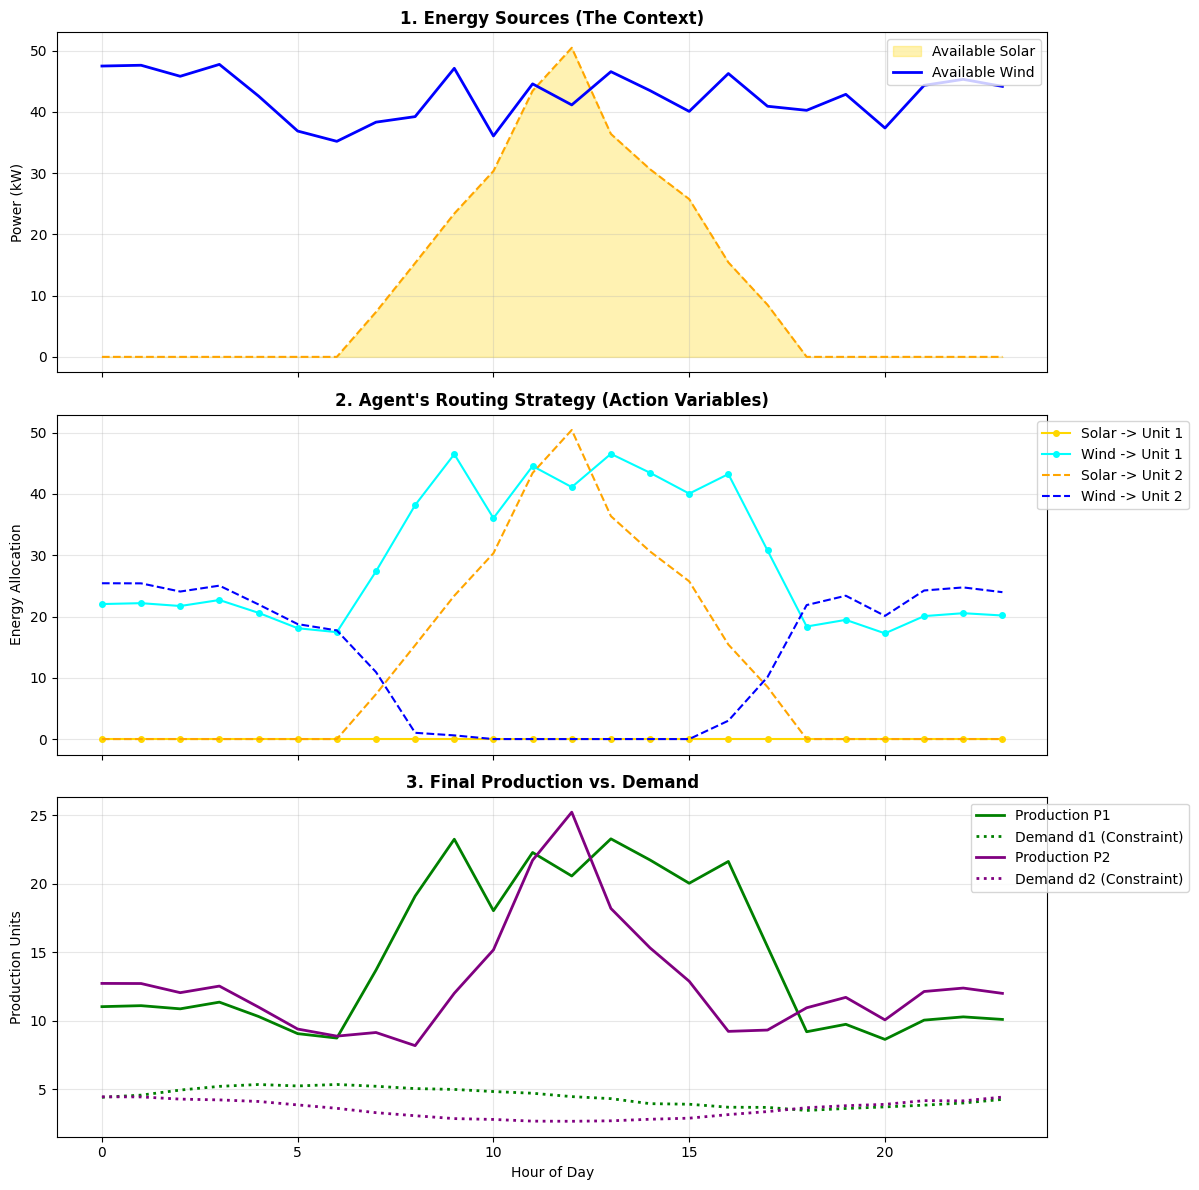

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO

def visualize_agent_performance():
    # 1. Load Environment and Agent
    env = InitialEnv(n_hours=24, alpha=0.5, beta=0.5)
    model = PPO.load("ppo_simplex_agent")

    # 2. Run a Single Episode
    obs, _ = env.reset()
    
    history = {
        "E11": [], "E12": [], "E21": [], "E22": [],
        "P1": [], "P2": [],
        "d1": [], "d2": [],
        "Solar": [], "Wind": []
    }
    
    time_steps = []
    
    print("Running Agent on a Random Day...")
    terminated = False
    while not terminated:
        # deterministic=True tells the agent to use its BEST action, not explore
        action, _ = model.predict(obs, deterministic=True)
        
        obs, reward, terminated, truncated, info = env.step(action)
        
        # Store data
        history["E11"].append(info["E11"]) # Solar -> P1
        history["E12"].append(info["E12"]) # Solar -> P2
        history["E21"].append(info["E21"]) # Wind -> P1
        history["E22"].append(info["E22"]) # Wind -> P2
        history["P1"].append(info["P1"])
        history["P2"].append(info["P2"])
        history["d1"].append(info["demand_1"])
        history["d2"].append(info["demand_2"])
        history["Solar"].append(info["solar"])
        history["Wind"].append(info["wind"])
        
        time_steps.append(info["t"])

    # 3. Create the Visualization
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    
    # --- Plot 1: Source Availability (Context) ---
    ax0 = axes[0]
    ax0.fill_between(time_steps, history["Solar"], color='gold', alpha=0.3, label="Available Solar")
    ax0.plot(time_steps, history["Solar"], color='orange', linestyle='--')
    ax0.plot(time_steps, history["Wind"], color='blue', label="Available Wind", linewidth=2)
    ax0.set_title("1. Energy Sources (The Context)", fontsize=12, fontweight='bold')
    ax0.set_ylabel("Power (kW)")
    ax0.legend(loc="upper right")
    ax0.grid(True, alpha=0.3)

    # --- Plot 2: Internal Routing (The Strategy) ---
    ax1 = axes[1]
    # Stacked plot to see how P1 and P2 are fed
    ax1.plot(time_steps, history["E11"], label="Solar -> Unit 1", color='gold', marker='o', markersize=4)
    ax1.plot(time_steps, history["E21"], label="Wind -> Unit 1", color='cyan', marker='o', markersize=4)
    ax1.plot(time_steps, history["E12"], label="Solar -> Unit 2", color='orange', linestyle='--')
    ax1.plot(time_steps, history["E22"], label="Wind -> Unit 2", color='blue', linestyle='--')
    
    ax1.set_title("2. Agent's Routing Strategy (Action Variables)", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Energy Allocation")
    ax1.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
    ax1.grid(True, alpha=0.3)

    # --- Plot 3: Production vs Constraints (The Result) ---
    ax2 = axes[2]
    # P1
    ax2.plot(time_steps, history["P1"], color='green', linewidth=2, label="Production P1")
    ax2.plot(time_steps, history["d1"], color='green', linestyle=':', linewidth=2, label="Demand d1 (Constraint)")
    # P2
    ax2.plot(time_steps, history["P2"], color='purple', linewidth=2, label="Production P2")
    ax2.plot(time_steps, history["d2"], color='purple', linestyle=':', linewidth=2, label="Demand d2 (Constraint)")
    
    ax2.set_title("3. Final Production vs. Demand", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Hour of Day")
    ax2.set_ylabel("Production Units")
    ax2.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_agent_performance()

In [ ]:
import gymnasium as gym
from stable_baselines3 import PPO
import numpy as np

def run_baseline_comparison():
    print("Loading environment and trained model...")
    
    # 1. Instantiate the testing environment
    env = InitialEnv(n_hours=24, alpha=0.5, beta=0.5)

    # 2. Load the trained "brain"
    model = PPO.load("ppo_simplex_agent")

    # 3. Reset the environment with a FIXED seed. 
    # This guarantees the solar, wind, and demand profiles are locked in.
    test_seed = 42
    obs, _ = env.reset(seed=test_seed)

    # 4. Calculate the perfect mathematical baseline using OR-Tools
    print(f"\nSolving episode (seed={test_seed}) with Linear Programming...")
    optimal_reward = calculate_optimal_episode_reward(
        env.solar, env.wind, env.demand_1, env.demand_2, 
        a=env.a, b=env.b, plot=False  # Set plot=True if you want to see the LP's graph
    )

    # 5. Run the trained RL agent on the exact same episode
    print("Running RL Agent...")
    rl_reward = 0.0
    terminated = False
    
    while not terminated:
        # deterministic=True ensures the agent picks its best learned action
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        rl_reward += reward

    # 6. Compare the results
    print("\n" + "="*40)
    print("🏆 COMPARISON RESULTS 🏆")
    print("="*40)
    print(f"Optimal LP Reward:  {optimal_reward:.2f}")
    print(f"RL Agent Reward:    {rl_reward:.2f}")
    
    if optimal_reward > 0:
        efficiency = (rl_reward / optimal_reward) * 100
        print(f"Agent Efficiency:   {efficiency:.2f}%")
        
        if efficiency >= 95.0:
            print("\n✅ Milestone 1 Passed: The agent matches the optimal baseline!")
        else:
            print("\n⚠️ The agent is falling short of the optimal mathematical allocation.")
    else:
        print("\nOptimal reward was 0 or negative. Check if the episode is feasible.")

if __name__ == "__main__":
    run_baseline_comparison()

Loading environment and trained model...

Solving episode (seed=42) with Linear Programming...
Running RL Agent...

🏆 COMPARISON RESULTS 🏆
Optimal LP Reward:  678.61
RL Agent Reward:    678.61
Agent Efficiency:   100.00%

✅ Milestone 1 Passed: The agent matches the optimal baseline!


In [ ]:
def test_asymmetry():
    # 1. Create an ASYMMETRIC environment
    env = InitialEnv(n_hours=24, alpha=0.9, beta=0.4)
    
    # 2. Load your currently trained agent
    model = PPO.load("ppo_simplex_agent")
    
    test_seed = 42
    obs, _ = env.reset(seed=test_seed)
    
    # 3. Calculate optimal LP for the asymmetric setup
    optimal_reward = calculate_optimal_episode_reward(
        env.solar, env.wind, env.demand_1, env.demand_2, 
        a=env.a, b=env.b, plot=False
    )
    
    # 4. Run your agent
    rl_reward = 0.0
    terminated = False
    while not terminated:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        rl_reward += reward
        
    print(f"Asymmetric LP Reward:  {optimal_reward:.2f}")
    print(f"Asymmetric RL Reward:  {rl_reward:.2f}")
    print(f"Agent Efficiency:      {(rl_reward / optimal_reward) * 100:.2f}%")

if __name__ == "__main__":
    test_asymmetry()

Asymmetric LP Reward:  1116.75
Asymmetric RL Reward:  915.44
Agent Efficiency:      81.97%


In [ ]:
def train_asymmetric_agent():
    print("Training new agent on Asymmetric Environment...")
    
    # 1. Create the ASYMMETRIC training environment
    env = make_vec_env(lambda: InitialEnv(n_hours=24, alpha=0.9, beta=0.4), n_envs=1)

    # 2. Initialize a fresh brain
    model = PPO(
        "MlpPolicy", 
        env, 
        verbose=0, # Set to 0 to keep your console clean, or 1 if you want to watch the rollout
        learning_rate=0.0003,
        batch_size=64,
        gamma=0.99 
    )

    # 3. Train it (100k timesteps should be plenty for this)
    model.learn(total_timesteps=100_000)
    
    # 4. Save the new model
    model.save("ppo_asymmetric_agent")
    print("Asymmetric Model saved!")

if __name__ == "__main__":
    train_asymmetric_agent()

Training new agent on Asymmetric Environment...
Asymmetric Model saved!


In [ ]:
def test_asymmetry():
    # 1. Create an ASYMMETRIC environment
    env = InitialEnv(n_hours=24, alpha=0.9, beta=0.4)
    
    # 2. Load your currently trained agent
    model = PPO.load("ppo_asymmetric_agent")
    
    test_seed = 42
    obs, _ = env.reset(seed=test_seed)
    
    # 3. Calculate optimal LP for the asymmetric setup
    optimal_reward = calculate_optimal_episode_reward(
        env.solar, env.wind, env.demand_1, env.demand_2, 
        a=env.a, b=env.b, plot=False
    )
    
    # 4. Run your agent
    rl_reward = 0.0
    terminated = False
    while not terminated:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        rl_reward += reward
        
    print(f"Asymmetric LP Reward:  {optimal_reward:.2f}")
    print(f"Asymmetric RL Reward:  {rl_reward:.2f}")
    print(f"Agent Efficiency:      {(rl_reward / optimal_reward) * 100:.2f}%")

if __name__ == "__main__":
    test_asymmetry()

Asymmetric LP Reward:  1116.75
Asymmetric RL Reward:  899.35
Agent Efficiency:      80.53%
